Quick inspection of the Excel file containing binary ML results to check sheet
names, structure, and column layout.

This cell:
1. Mounts Google Drive in Colab and loads the `SI_1_ML_Results_Binary_Multiclass.xlsx`
   workbook, printing all available sheet names to verify the file structure.
2. Reads the `ml_results_binary` sheet into a DataFrame and prints its shape,
   the first few rows, and the full list of column names so you can confirm
   that metrics, model IDs, and misclassification columns are present and
   correctly formatted before running downstream statistical analyses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Path to your Excel file (complete the path with your folder structure)
file_path = '/content/drive/My Drive/SI_1_ML_Results_Binary_Multiclass.xlsx'

# Load the Excel file
xls = pd.ExcelFile(file_path)

# Print all sheet names to see what we have
print("Available sheets:")
print(xls.sheet_names)
print("\n" + "="*50 + "\n")

# Read a specific sheet by name
sheet_name = 'ml_results_binary'
df = pd.read_excel(file_path, sheet_name=sheet_name)

print(f"Sheet: {sheet_name}")
print("\nShape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nColumn names:")
print(df.columns.tolist())

Mounted at /content/drive
Available sheets:
['ml_results_binary', 'training_dynamics_binary', 'stat_comparison_binary', 'ml_results_multiclass', 'training_dynamics_multiclass', 'stat_comparison_multiclass']


Sheet: ml_results_binary

Shape: (30, 18)

First few rows:
             Model  Accuracy  Loss  Total number of Miscalssifications  \
0    Custom_CNN_f1      0.93  0.25                                   9   
1    Custom_CNN_f2      0.95  0.25                                   6   
2    Custom_CNN_f3      0.96  0.20                                   5   
3    Custom_CNN_f4      0.97  0.19                                   3   
4    Custom_CNN_f5      0.94  0.23                                   7   
5  Custom_CNN_test      0.95  0.19                                   6   
6           BNN_f1      0.96  0.47                                   7   
7           BNN_f2      0.92  0.56                                  10   
8           BNN_f3      0.92  0.52                                

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Path to your Excel file (complete the path with your folder structure)
file_path = '/content/drive/My Drive/SI_1_ML_Results_Binary_Multiclass.xlsx'

# Load the Excel file
xls = pd.ExcelFile(file_path)

# Print all sheet names to see what we have
print("Available sheets:")
print(xls.sheet_names)
print("\n" + "="*50 + "\n")

# Read a specific sheet by name
sheet_name = 'ml_results_multiclass'
df = pd.read_excel(file_path, sheet_name=sheet_name)

print(f"Sheet: {sheet_name}")
print("\nShape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nColumn names:")
print(df.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Available sheets:
['ml_results_binary', 'training_dynamics_binary', 'stat_comparison_binary', 'ml_results_multiclass', 'training_dynamics_multiclass', 'stat_comparison_multiclass']


Sheet: ml_results_multiclass

Shape: (30, 23)

First few rows:
             Model  Accuracy  Loss  Total number of misclassifications  \
0    Custom_CNN_f1      0.95  0.14                                   3   
1    Custom_CNN_f2      0.90  0.36                                   6   
2    Custom_CNN_f3      0.86  0.39                                   8   
3    Custom_CNN_f4      0.94  0.18                                   3   
4    Custom_CNN_f5      0.96  0.22                                   2   
5  Custom_CNN_test      0.96  0.12                                   3   
6           BNN_f1      0.88  0.38                                   5   
7           BNN_f2      0.81  0.4

Compares how many errors each model makes in the binary and multiclass tasks
using stacked bar charts of average misclassifications per class.

This cell:
1. Loads binary and multiclass cross-validation results from the Excel file,
   strips fold/test suffixes to recover base model names, and groups by
   `Base_Model` to compute mean misclassification counts (and standard
   deviations) for each class in the binary (Non-Frost, Frost) and multiclass
   (Blocky, Granular, Platy-Lenticular) settings.
2. Builds a two-panel figure where the top panel shows stacked bars of average
   Non-Frost and Frost misclassifications per model, and the bottom panel
   shows stacked bars of average Blocky, Granular, and Platy-Lenticular
   misclassifications per model, using a colorblind-safe palette and clear
   axis labels.
3. Annotates each colored segment with its class-specific mean error count and
   prints the total mean misclassifications on top of each stack, and adds
   panel labels ((a) binary, (b) multiclass) plus separate legends for the
   binary and multiclass panels on the right.
4. Saves the combined figure as a high-resolution `.tif` file
   (`combined_misclassifications_stacked.tif`) for inclusion in the manuscript
   or supplementary material.

Available columns in multiclass data:
['Total number of misclassifications', 'Misclassifications Blocky', 'Misclassifications Granular', 'Misclassifications Platy-Lenticular']
Figure saved to: /content/drive/My Drive/combined_misclassifications_stacked_median.tif


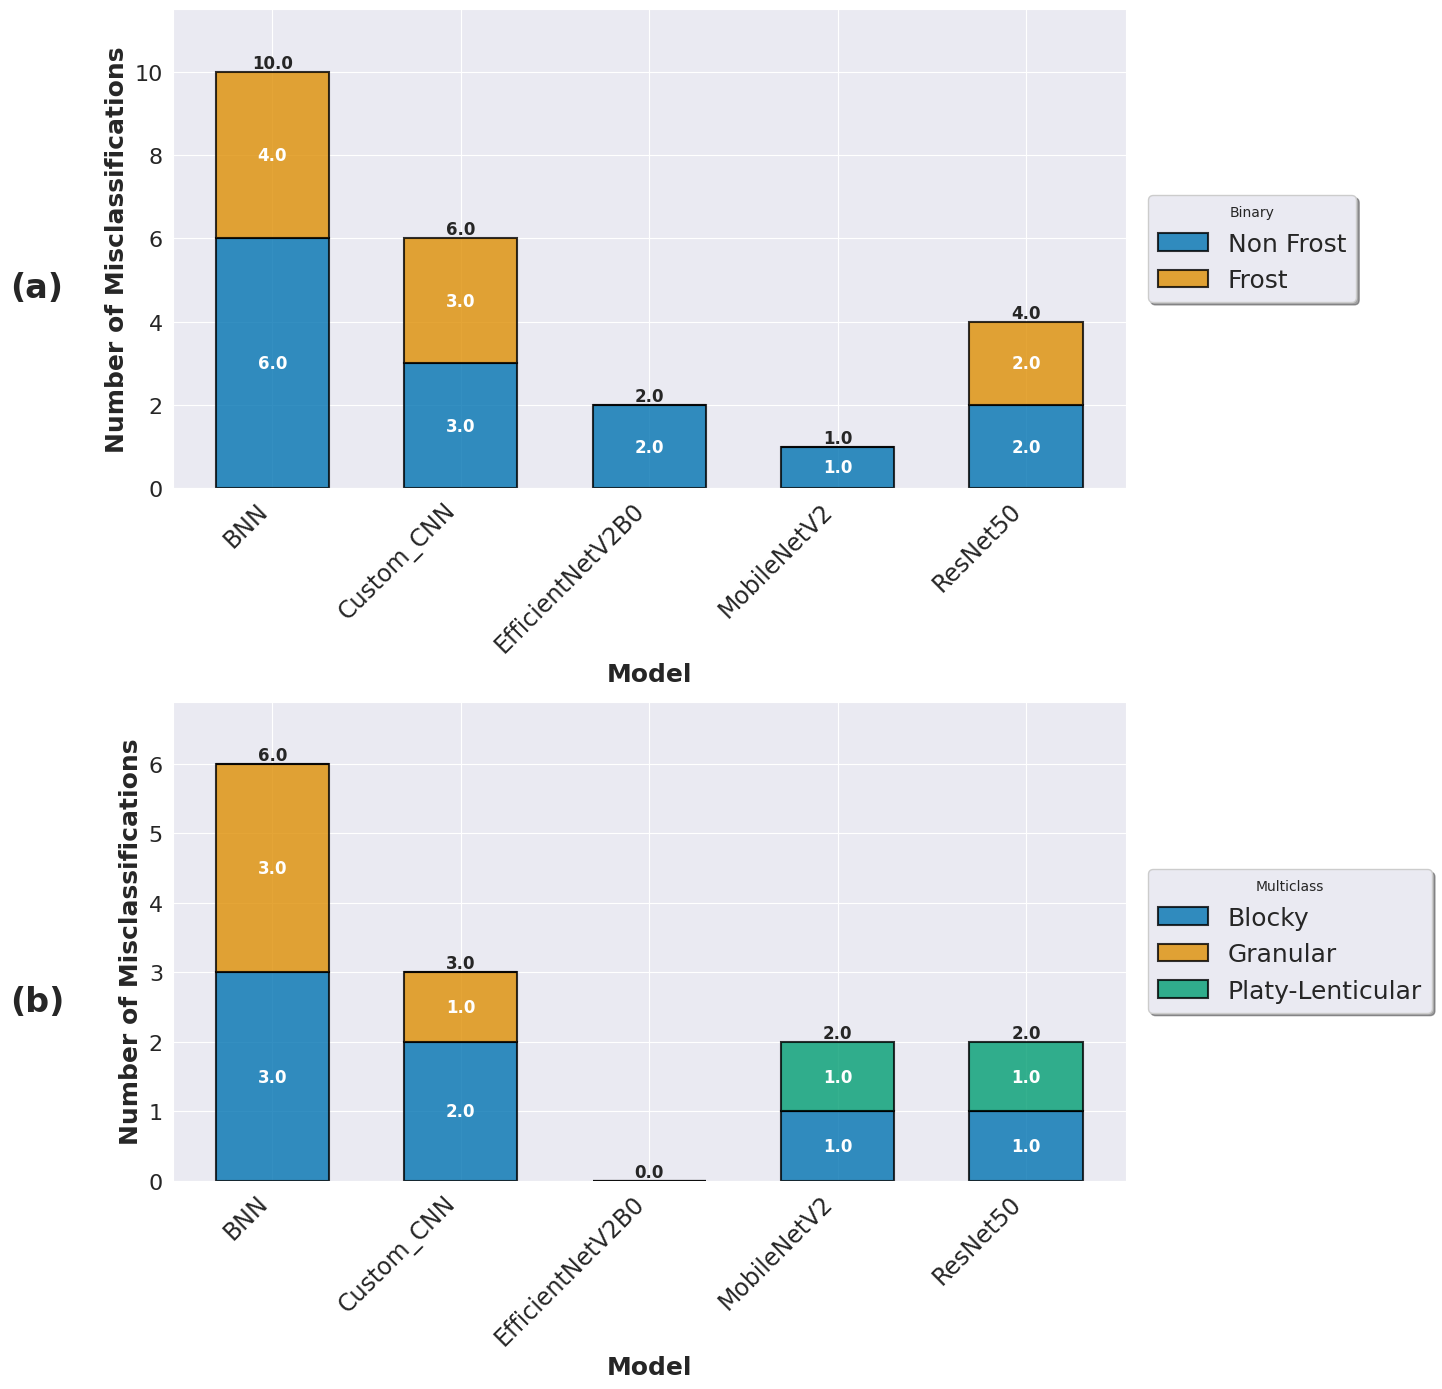

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# ==========================================
# READ AND PREPARE BINARY DATA
# ==========================================
df_binary = pd.read_excel(file_path, sheet_name='ml_results_binary')
df_binary['Base_Model'] = df_binary['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_binary_cv = df_binary[df_binary['Model'].str.contains(r'_f\d', regex=True)].copy()

# Calculate misclassification statistics for binary - USING MEDIAN
stats_misclass_binary = df_binary_cv.groupby('Base_Model').agg({
    'Misclassification Non Frost': ['median'],
    'Misclassifications Frost': ['median']
})

# ==========================================
# READ AND PREPARE MULTICLASS DATA
# ==========================================
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_multi_cv = df_multi[df_multi['Model'].str.contains(r'_f\d', regex=True)].copy()

# Check what misclassification columns exist in multiclass data
print("Available columns in multiclass data:")
print([col for col in df_multi_cv.columns if 'isclass' in col.lower()])

# Calculate misclassification statistics for multiclass - USING MEDIAN
# Try with possible column name variations
try:
    stats_misclass_multi = df_multi_cv.groupby('Base_Model').agg({
        'Misclassifications Blocky': ['median'],
        'Misclassifications Granular': ['median'],
        'Misclassifications Platy-Lenticular': ['median']
    })
except KeyError:
    # If that doesn't work, try without 's'
    stats_misclass_multi = df_multi_cv.groupby('Base_Model').agg({
        'Misclassification Blocky': ['median'],
        'Misclassification Granular': ['median'],
        'Misclassification Platy-Lenticular': ['median']
    })

# ==========================================
# CREATE 2x1 SUBPLOT LAYOUT
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

# Use colorblind-friendly palette
colorblind_palette = sns.color_palette('colorblind')

# ==========================================
# PLOT BINARY MISCLASSIFICATIONS (TOP)
# ==========================================
ax = axes[0]

colors_binary = [colorblind_palette[0], colorblind_palette[1]]  # Blue, Orange
x_binary = np.arange(len(stats_misclass_binary.index))

medians_non_frost = stats_misclass_binary['Misclassification Non Frost']['median']
medians_frost = stats_misclass_binary['Misclassifications Frost']['median']

# Create stacked bars
bars1 = ax.bar(x_binary, medians_non_frost, width=0.6, label='Non Frost',
               color=colors_binary[0], edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x_binary, medians_frost, width=0.6, bottom=medians_non_frost, label='Frost',
               color=colors_binary[1], edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Misclassifications', fontsize=18, fontweight='bold')
#ax.set_title('Median Misclassifications Across 5 CV Folds', fontsize=18, fontweight='bold')
ax.set_xticks(x_binary)
ax.set_xticklabels(stats_misclass_binary.index, rotation=45, ha='right', fontsize=17)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylim(0, max(medians_non_frost + medians_frost) * 1.15)

# Add value labels for stacked bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.3:  # Only show label if segment is visible
            y_pos = bar.get_y() + height / 2
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   f'{height:.1f}',
                   ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Add total on top of each bar
for i in range(len(x_binary)):
    total = medians_non_frost.iloc[i] + medians_frost.iloc[i]
    ax.text(i, total, f'{total:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add legend for binary
handles_binary, labels_binary = ax.get_legend_handles_labels()
ax.legend(handles_binary, labels_binary,
          loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=18, frameon=True, shadow=True, markerscale=1.5,
          title='Binary')

# Add (a) label
fig.text(-0.02, 0.79, '(a)', fontsize=24, fontweight='bold', va='center')

# ==========================================
# PLOT MULTICLASS MISCLASSIFICATIONS (BOTTOM)
# ==========================================
ax = axes[1]

colors_multi = [colorblind_palette[0], colorblind_palette[1], colorblind_palette[2]]  # Blue, Orange, Green
x_multi = np.arange(len(stats_misclass_multi.index))

# Get the first column name to determine if it's 'Misclassification' or 'Misclassifications'
first_col = list(stats_misclass_multi.columns.levels[0])[0]
col_prefix = 'Misclassifications' if first_col.startswith('Misclassifications') else 'Misclassification'

medians_blocky = stats_misclass_multi[first_col]['median']
medians_granular = stats_misclass_multi[list(stats_misclass_multi.columns.levels[0])[1]]['median']
medians_platy = stats_misclass_multi[list(stats_misclass_multi.columns.levels[0])[2]]['median']

# Create stacked bars
bars1 = ax.bar(x_multi, medians_blocky, width=0.6, label='Blocky',
               color=colors_multi[0], edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax.bar(x_multi, medians_granular, width=0.6, bottom=medians_blocky, label='Granular',
               color=colors_multi[1], edgecolor='black', linewidth=1.5, alpha=0.8)
bars3 = ax.bar(x_multi, medians_platy, width=0.6, bottom=medians_blocky + medians_granular,
               label='Platy-Lenticular', color=colors_multi[2], edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Misclassifications', fontsize=18, fontweight='bold')
#ax.set_title('Median Misclassifications Across 5 CV Folds', fontsize=18, fontweight='bold')
ax.set_xticks(x_multi)
ax.set_xticklabels(stats_misclass_multi.index, rotation=45, ha='right', fontsize=17)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylim(0, max(medians_blocky + medians_granular + medians_platy) * 1.15)

# Add value labels for stacked bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.3:  # Only show label if segment is visible
            y_pos = bar.get_y() + height / 2
            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                   f'{height:.1f}',
                   ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Add total on top of each bar
for i in range(len(x_multi)):
    total = medians_blocky.iloc[i] + medians_granular.iloc[i] + medians_platy.iloc[i]
    ax.text(i, total, f'{total:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add legend for multiclass
handles_multi, labels_multi = ax.get_legend_handles_labels()
ax.legend(handles_multi, labels_multi,
          loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=18, frameon=True, shadow=True, markerscale=1.5,
          title='Multiclass')

# Add (b) label
fig.text(-0.02, 0.28, '(b)', fontsize=24, fontweight='bold', va='center')

# ==========================================
# ADJUST LAYOUT AND SAVE
# ==========================================
plt.tight_layout(rect=[0.03, 0, 0.88, 1])

# Save the figure
output_path = '/content/drive/My Drive/combined_misclassifications_stacked_median.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

Creates a publication-ready comparison of per-class precision, recall, and F1
across models for both binary and multiclass classification, with a consistent
color scheme.

This cell:
1. Loads binary and multiclass result sheets, strips fold/test suffixes to
   obtain base model names, filters to cross-validation runs, and aggregates
   mean and standard deviation of precision, recall, and F1 for each class and
   model.
2. Defines a fixed, colorblind-friendly palette where each class (Non-Frost,
   Frost, Blocky, Granular, Platy-Lenticular) has a unique color that is used
   consistently across all subplots.
3. Builds a 2×3 figure: the top row shows grouped bar plots (with asymmetric
   error bars) of Non-Frost vs Frost precision, recall, and F1 across models;
   the bottom row shows Blocky, Granular, and Platy-Lenticular precision,
   recall, and F1 across models, all on a 0–100% scale with clear labels and
   panel markers (a) and (b).
4. Places separate legends for the binary and multiclass rows on the right,
   reserves space for them via `tight_layout`, and saves the combined figure as
   a high-resolution `.tif` file (`combined_classification_performance2.tif`)
   suitable for inclusion in the manuscript or supplementary material.

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_320/2902825001.py:14: SyntaxWarning: invalid escape sequence '\d'
  df_binary_cv = df_binary[df_binary['Model'].str.contains('_f\d', regex=True)].copy()
/tmp/ipykernel_320/2902825001.py:30: SyntaxWarning: invalid escape sequence '\d'
  df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()


Figure saved to: /content/drive/My Drive/combined_classification_performance2.tif


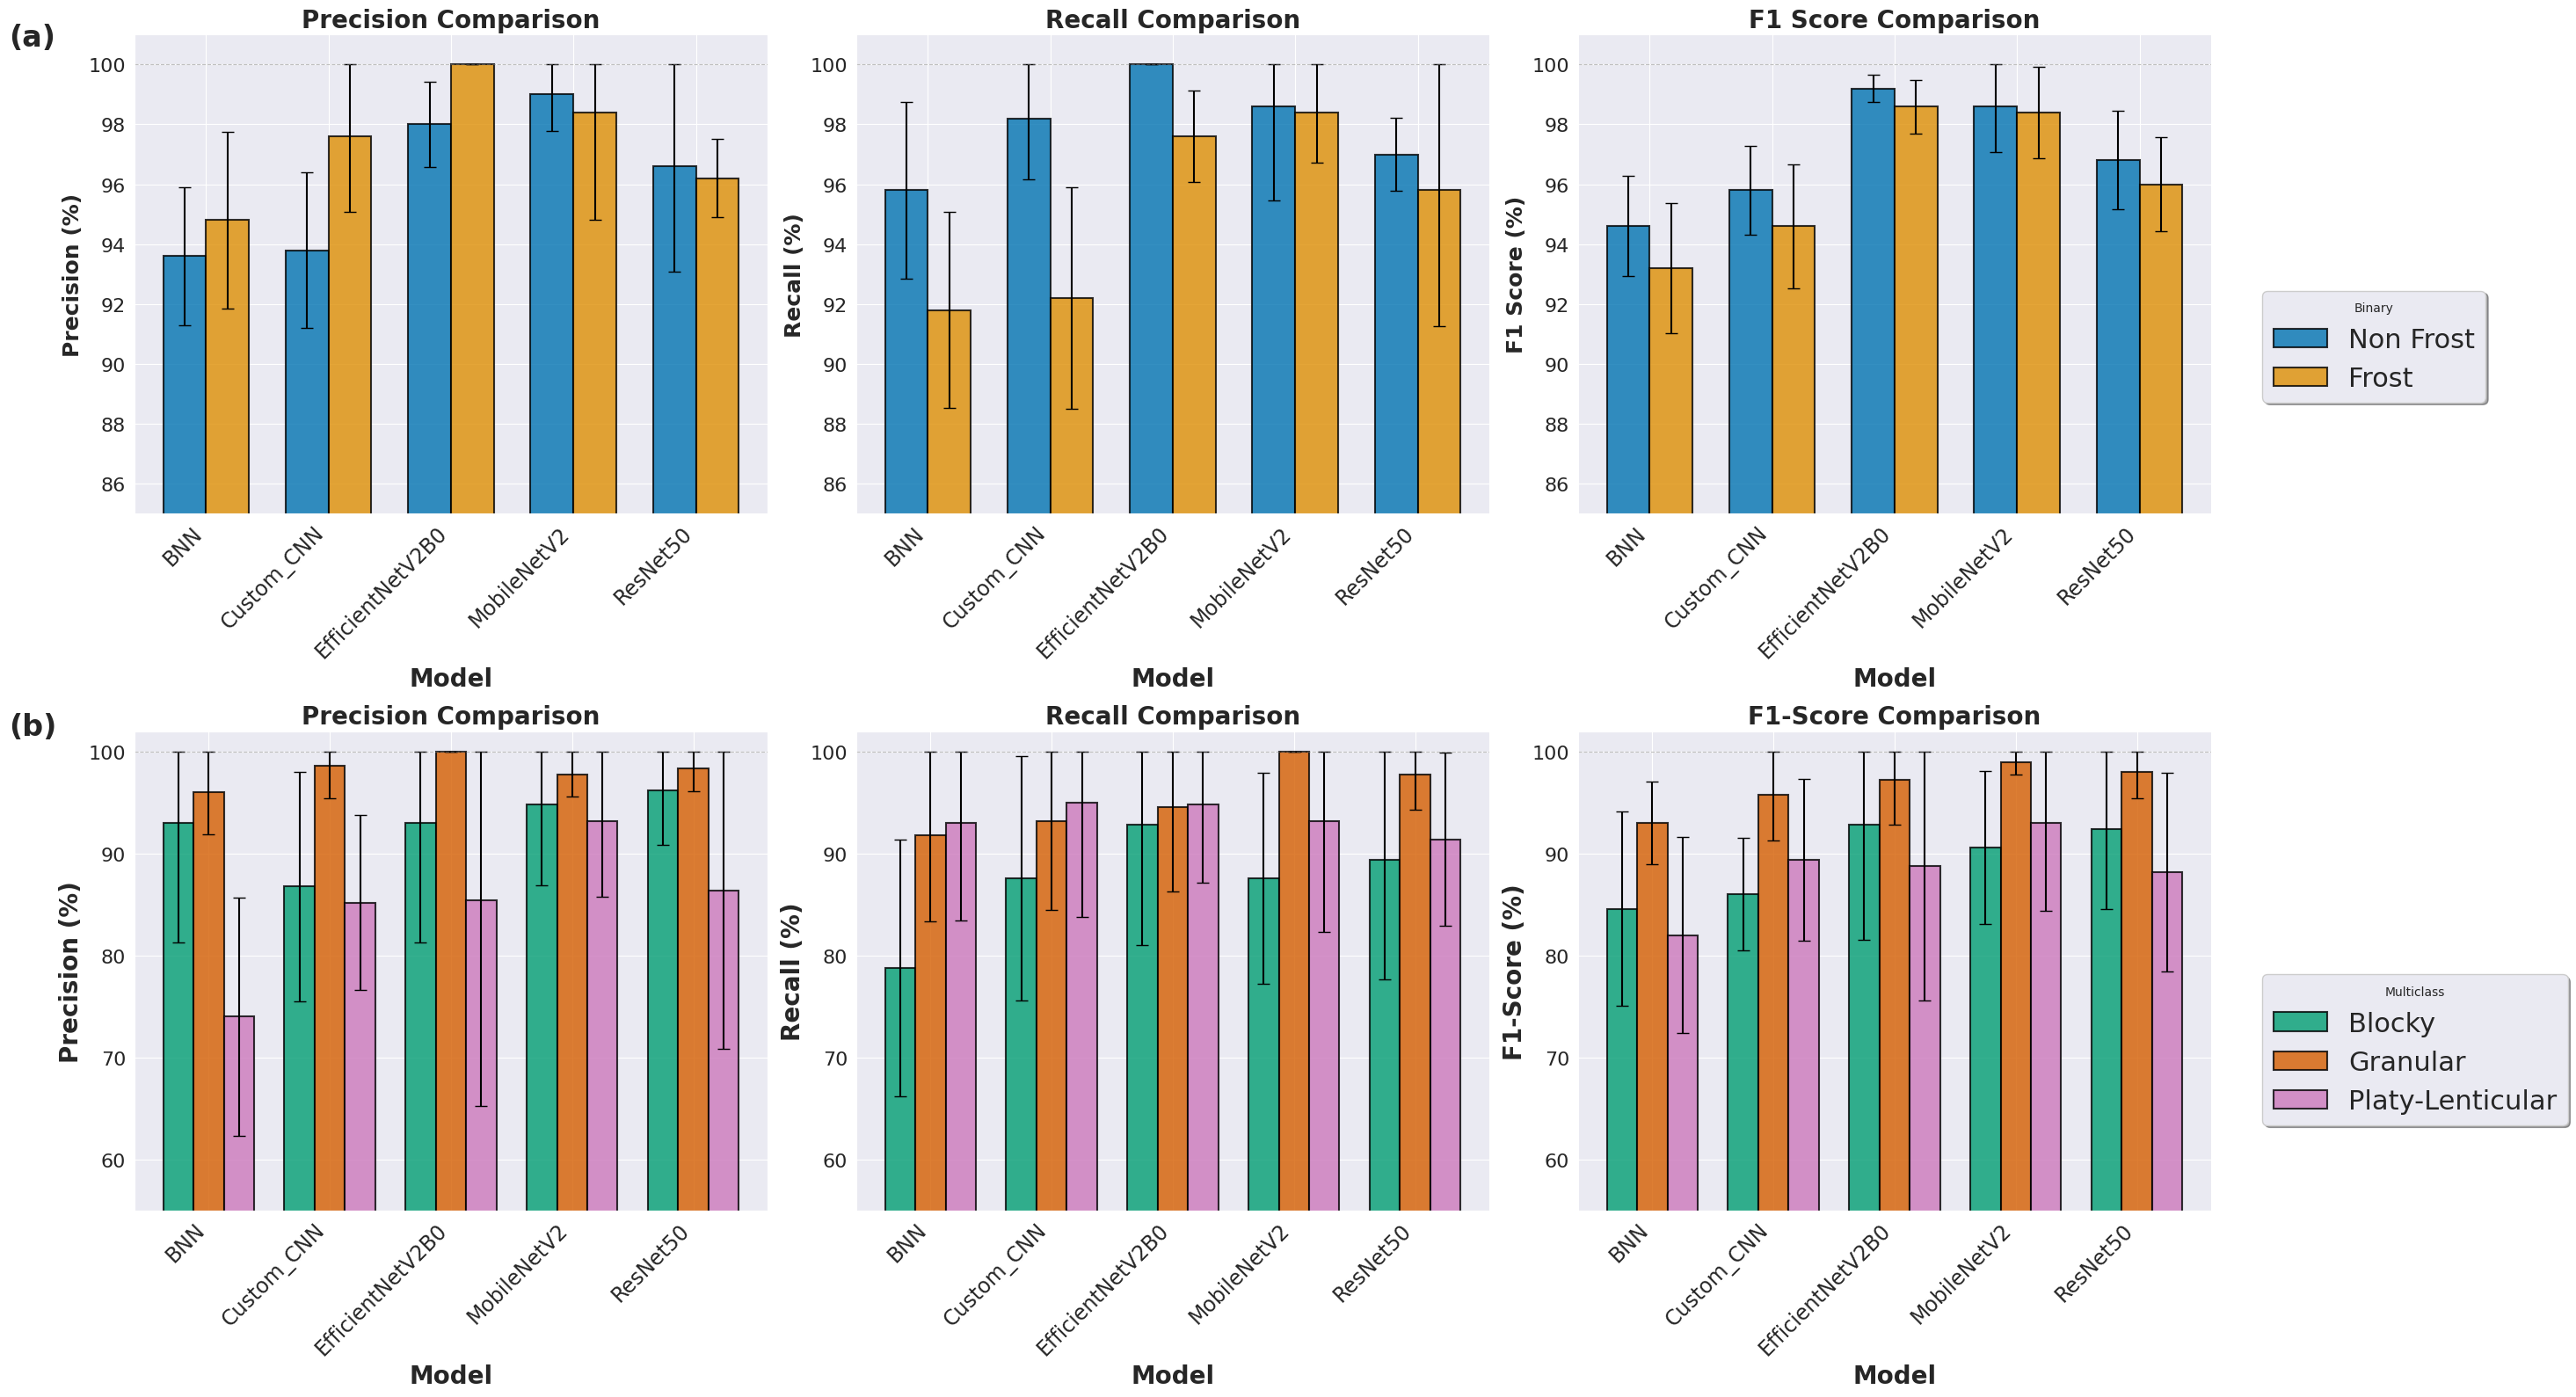

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# ==========================================
# READ AND PREPARE BINARY DATA
# ==========================================
df_binary = pd.read_excel(file_path, sheet_name='ml_results_binary')
df_binary['Base_Model'] = df_binary['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_binary_cv = df_binary[df_binary['Model'].str.contains('_f\d', regex=True)].copy()

stats_binary = df_binary_cv.groupby('Base_Model').agg({
    'Precision Non Frost': ['mean', 'std'],
    'Recall Non Frost': ['mean', 'std'],
    'F1 Score Non frost': ['mean', 'std'],
    'Precision Frost': ['mean', 'std'],
    'Recall Frost': ['mean', 'std'],
    'F1 Score Frost': ['mean', 'std']
})

# ==========================================
# READ AND PREPARE MULTICLASS DATA
# ==========================================
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()

stats_multi = df_multi_cv.groupby('Base_Model').agg({
    'Precision  Blocky': ['mean', 'std'],
    'Recall Blocky': ['mean', 'std'],
    'F1-Score Blocky': ['mean', 'std'],
    'Precision Granular': ['mean', 'std'],
    'Recall Granular': ['mean', 'std'],
    'F1-Score Granular': ['mean', 'std'],
    'Precision Platy-Lenticular': ['mean', 'std'],
    'Recall Platy-Lenticular': ['mean', 'std'],
    'F1-Score Platy-Lenticular': ['mean', 'std']
})

# ==========================================
# DEFINE CONSISTENT COLOR SCHEME
# ==========================================
colorblind_palette = sns.color_palette('colorblind')

# Assign a unique color to each class across both plots (matching previous figure)
color_non_frost = colorblind_palette[0]      # Blue
color_frost_binary = colorblind_palette[1]   # Orange
color_blocky = colorblind_palette[2]         # Green
color_granular = colorblind_palette[3]       # Red
color_platy = colorblind_palette[4]          # Purple

# ==========================================
# CREATE 2x3 SUBPLOT LAYOUT
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(28, 16))
plt.subplots_adjust(hspace=0.4)

# ==========================================
# PLOT BINARY CLASSIFICATION (TOP ROW)
# ==========================================
metrics_binary = [
    ('Precision', 'Precision Non Frost', 'Precision Frost'),
    ('Recall', 'Recall Non Frost', 'Recall Frost'),
    ('F1 Score', 'F1 Score Non frost', 'F1 Score Frost')
]

x_binary = np.arange(len(stats_binary.index))
width_binary = 0.35
colors_binary = [color_non_frost, color_frost_binary]  # Blue and Orange

for idx, (metric_name, non_frost_col, frost_col) in enumerate(metrics_binary):
    ax = axes[0, idx]  # First row

    # Get means and stds and convert to percentages
    means_non_frost = stats_binary[non_frost_col]['mean'] * 100
    stds_non_frost = stats_binary[non_frost_col]['std'] * 100
    means_frost = stats_binary[frost_col]['mean'] * 100
    stds_frost = stats_binary[frost_col]['std'] * 100

    # Calculate error bars
    upper_err_non_frost = np.minimum(stds_non_frost, 100 - means_non_frost)
    upper_err_frost = np.minimum(stds_frost, 100 - means_frost)
    lower_err_non_frost = stds_non_frost
    lower_err_frost = stds_frost

    errors_non_frost = [lower_err_non_frost, upper_err_non_frost]
    errors_frost = [lower_err_frost, upper_err_frost]

    # Create grouped bars
    bars1 = ax.bar(x_binary - width_binary/2, means_non_frost, width_binary, yerr=errors_non_frost,
                   capsize=5, label='Non Frost', color=colors_binary[0],
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    bars2 = ax.bar(x_binary + width_binary/2, means_frost, width_binary, yerr=errors_frost,
                   capsize=5, label='Frost', color=colors_binary[1],
                   edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=20, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=18, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=20, fontweight='bold')
    ax.set_xticks(x_binary)
    ax.set_xticklabels(stats_binary.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(85, 101)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='y', labelsize=16)

# ==========================================
# PLOT MULTICLASS CLASSIFICATION (BOTTOM ROW)
# ==========================================
metrics_multi = [
    ('Precision', 'Precision  Blocky', 'Precision Granular', 'Precision Platy-Lenticular'),
    ('Recall', 'Recall Blocky', 'Recall Granular', 'Recall Platy-Lenticular'),
    ('F1-Score', 'F1-Score Blocky', 'F1-Score Granular', 'F1-Score Platy-Lenticular')
]

x_multi = np.arange(len(stats_multi.index))
width_multi = 0.25
colors_multi = [color_blocky, color_granular, color_platy]  # Green, Red, Purple
class_names = ['Blocky', 'Granular', 'Platy-Lenticular']

for idx, (metric_name, blocky_col, granular_col, platy_col) in enumerate(metrics_multi):
    ax = axes[1, idx]  # Second row

    columns = [blocky_col, granular_col, platy_col]

    for class_idx, (col, class_name, color) in enumerate(zip(columns, class_names, colors_multi)):
        # Get means and stds and convert to percentages
        means = stats_multi[col]['mean'] * 100
        stds = stats_multi[col]['std'] * 100

        # Calculate error bars
        upper_err = np.minimum(stds, 100 - means)
        lower_err = stds
        errors = [lower_err, upper_err]

        # Position bars
        position = x_multi + width_multi * (class_idx - 1)

        # Create grouped bars
        bars = ax.bar(position, means, width_multi, yerr=errors,
                     capsize=5, label=class_name, color=color,
                     edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=20, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=20, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=20, fontweight='bold')
    ax.set_xticks(x_multi)
    ax.set_xticklabels(stats_multi.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(55, 102)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='y', labelsize=16)

# ==========================================
# ADD (a) and (b) LABELS OUTSIDE PLOTS
# ==========================================
# Add (a) label outside top row - upper left
fig.text(0.01, 0.98, '(a)', fontsize=24, fontweight='bold', va='top', ha='left')

# Add (b) label outside bottom row - upper left
fig.text(0.01, 0.49, '(b)', fontsize=24, fontweight='bold', va='top', ha='left')

# ==========================================
# ADD LEGENDS ON THE RIGHT SIDE OF EACH ROW
# ==========================================
# Legend for binary (right side of top row)
handles_binary, labels_binary = axes[0, 0].get_legend_handles_labels()
legend_binary = fig.legend(handles_binary, labels_binary,
                          loc='center left', bbox_to_anchor=(0.92, 0.75),
                          fontsize=22, frameon=True, shadow=True, markerscale=1.5,
                          title='Binary')

# Legend for multiclass (right side of bottom row)
handles_multi, labels_multi = axes[1, 0].get_legend_handles_labels()
legend_multi = fig.legend(handles_multi, labels_multi,
                         loc='center left', bbox_to_anchor=(0.92, 0.25),
                         fontsize=22, frameon=True, shadow=True, markerscale=1.5,
                         title='Multiclass')

plt.tight_layout(rect=[0.025, 0, 0.91, 1])  # Leave space on the right for legends

# Save the figure
output_path = '/content/drive/My Drive/combined_classification_performance2.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

Summarizes and compares learning dynamics for each model across binary and
multiclass tasks, using five key training checkpoints.

This cell:
1. Loads precomputed training-dynamics tables (binary and multiclass) that
   store training/validation accuracy and loss at fixed points (initial,
   25%, middle, 75%, final) for each cross-validation fold, and restructures
   them by base model so that all fold-level values for each stage are
   grouped together.
2. Computes per-model means and standard deviations of these metrics at each
   training stage for both tasks, providing a compact summary of how accuracy
   increases and loss decreases over training, and how stable these trends are
   across folds.
3. Builds a figure with one row per model and two columns (left: accuracy,
   right: loss), where each subplot overlays four curves: binary train, binary
   validation, multiclass train, and multiclass validation, each with shaded
   bands showing ±1 standard deviation around the mean at the five time
   points.
4. Adds panel labels, consistent x-axis labels (“0%, 25%, 50%, 75%, 100%”
   training progress), a single shared legend at the bottom, and saves the
   final multi-panel figure as a high-resolution `.tif` file
   (`learning_dynamics_combined_5points.tif`) for inclusion in the paper or
   supplementary material.

Figure saved to: /content/drive/My Drive/learning_dynamics_combined_5points.tif


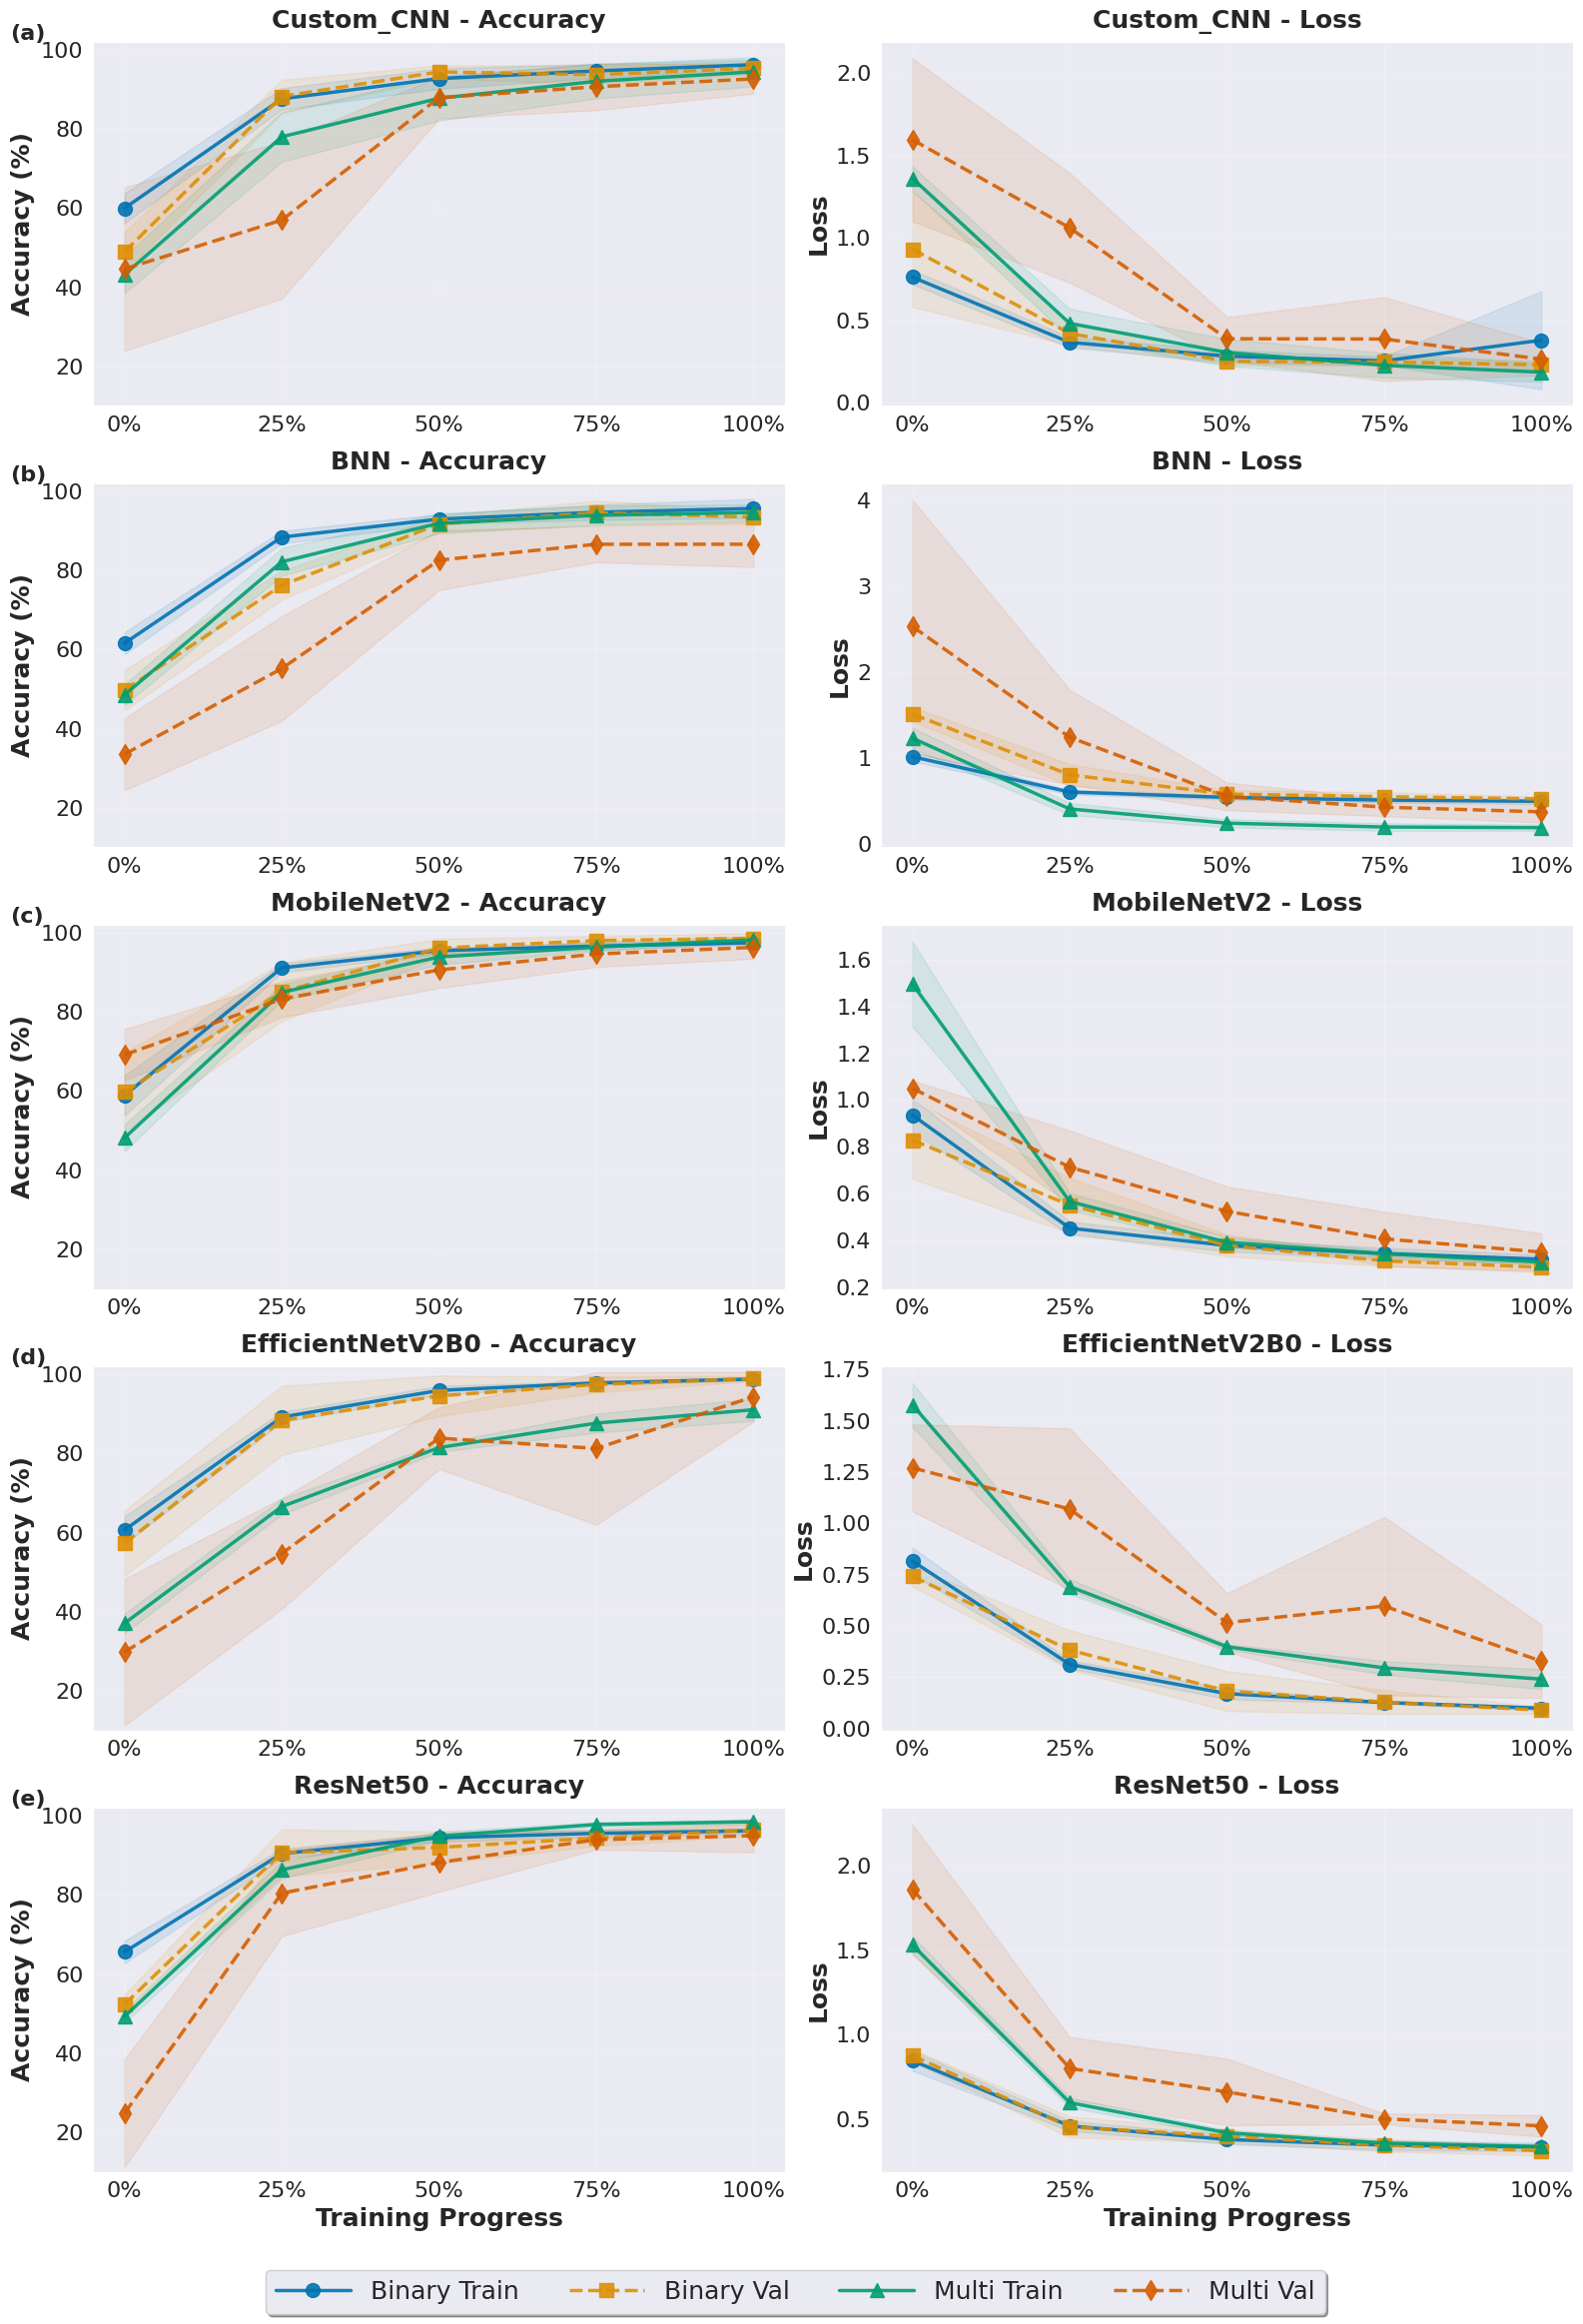

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

# Set seaborn style
sns.set_style('darkgrid')

# Read both binary and multiclass data
df_binary = pd.read_excel(file_path, sheet_name='training_dynamics_binary')
df_multiclass = pd.read_excel(file_path, sheet_name='training_dynamics_multiclass')

# Set the first column as index
df_binary = df_binary.set_index(df_binary.columns[0])
df_multiclass = df_multiclass.set_index(df_multiclass.columns[0])

# Extract model columns for both tasks
binary_columns = [col for col in df_binary.columns if '_f' in col]
multiclass_columns = [col for col in df_multiclass.columns if '_f' in col]

# Function to organize data by model
def organize_data(df, columns):
    models_data = {}
    for col in columns:
        base_model = col.rsplit('_f', 1)[0]
        if base_model not in models_data:
            models_data[base_model] = {
                'train_acc_initial': [], 'train_acc_25': [], 'train_acc_middle': [],
                'train_acc_75': [], 'train_acc_final': [],
                'val_acc_initial': [], 'val_acc_25': [], 'val_acc_middle': [],
                'val_acc_75': [], 'val_acc_final': [],
                'train_loss_initial': [], 'train_loss_25': [], 'train_loss_middle': [],
                'train_loss_75': [], 'train_loss_final': [],
                'val_loss_initial': [], 'val_loss_25': [], 'val_loss_middle': [],
                'val_loss_75': [], 'val_loss_final': []
            }

        models_data[base_model]['train_acc_initial'].append(df.loc['Training_intitial_accuracy', col])
        models_data[base_model]['train_acc_25'].append(df.loc['Training_25_accuracy', col])
        models_data[base_model]['train_acc_middle'].append(df.loc['Training_middle_accuracy', col])
        models_data[base_model]['train_acc_75'].append(df.loc['Training_75_accuracy', col])
        models_data[base_model]['train_acc_final'].append(df.loc['Training_final_accuracy', col])

        models_data[base_model]['val_acc_initial'].append(df.loc['Validation_initial_accuracy', col])
        models_data[base_model]['val_acc_25'].append(df.loc['Validation_25_accuracy', col])
        models_data[base_model]['val_acc_middle'].append(df.loc['Validation_middle_accuracy', col])
        models_data[base_model]['val_acc_75'].append(df.loc['Validation_75_accuracy', col])
        models_data[base_model]['val_acc_final'].append(df.loc['Validation_final_accuracy', col])

        models_data[base_model]['train_loss_initial'].append(df.loc['Training_intitial_loss', col])
        models_data[base_model]['train_loss_25'].append(df.loc['Training_25_loss', col])
        models_data[base_model]['train_loss_middle'].append(df.loc['Training_middle_loss', col])
        models_data[base_model]['train_loss_75'].append(df.loc['Training_75_loss', col])
        models_data[base_model]['train_loss_final'].append(df.loc['Training_final_loss', col])

        models_data[base_model]['val_loss_initial'].append(df.loc['Validation_initial_loss', col])
        models_data[base_model]['val_loss_25'].append(df.loc['Validation_25_loss', col])
        models_data[base_model]['val_loss_middle'].append(df.loc['Validation_middle_loss', col])
        models_data[base_model]['val_loss_75'].append(df.loc['Validation_75_loss', col])
        models_data[base_model]['val_loss_final'].append(df.loc['Validation_final_loss', col])

    return models_data

# Organize data for both tasks
binary_data = organize_data(df_binary, binary_columns)
multiclass_data = organize_data(df_multiclass, multiclass_columns)

# Calculate statistics
def calculate_stats(models_data):
    stats = {}
    for model, data in models_data.items():
        stats[model] = {}
        for key, values in data.items():
            stats[model][key] = {'mean': np.mean(values), 'std': np.std(values)}
    return stats

stats_binary = calculate_stats(binary_data)
stats_multiclass = calculate_stats(multiclass_data)

# Time points - now 5 points
time_points = [0, 1, 2, 3, 4]
time_labels = ['0%', '25%', '50%', '75%', '100%']

model_names = list(stats_binary.keys())
n_models = len(model_names)

# Create figure with 2 columns (Accuracy, Loss) and n_models rows
# Add extra space at bottom for shared legend
fig, axes = plt.subplots(n_models, 2, figsize=(16, 4.5*n_models + 0.5))
if n_models == 1:
    axes = axes.reshape(1, -1)

# Generate subplot labels
subplot_labels = list(string.ascii_lowercase)

# Color scheme
colors = {
    'binary_train': '#0173B2',
    'binary_val': '#DE8F05',
    'multiclass_train': '#029E73',
    'multiclass_val': '#D55E00'
}

for idx, model in enumerate(model_names):
    # LEFT: ACCURACY
    ax_acc = axes[idx, 0]

    # Binary Train - 5 points
    train_acc_means_bin = [
        stats_binary[model]['train_acc_initial']['mean'] * 100,
        stats_binary[model]['train_acc_25']['mean'] * 100,
        stats_binary[model]['train_acc_middle']['mean'] * 100,
        stats_binary[model]['train_acc_75']['mean'] * 100,
        stats_binary[model]['train_acc_final']['mean'] * 100
    ]
    train_acc_stds_bin = [
        stats_binary[model]['train_acc_initial']['std'] * 100,
        stats_binary[model]['train_acc_25']['std'] * 100,
        stats_binary[model]['train_acc_middle']['std'] * 100,
        stats_binary[model]['train_acc_75']['std'] * 100,
        stats_binary[model]['train_acc_final']['std'] * 100
    ]

    # Binary Val - 5 points
    val_acc_means_bin = [
        stats_binary[model]['val_acc_initial']['mean'] * 100,
        stats_binary[model]['val_acc_25']['mean'] * 100,
        stats_binary[model]['val_acc_middle']['mean'] * 100,
        stats_binary[model]['val_acc_75']['mean'] * 100,
        stats_binary[model]['val_acc_final']['mean'] * 100
    ]
    val_acc_stds_bin = [
        stats_binary[model]['val_acc_initial']['std'] * 100,
        stats_binary[model]['val_acc_25']['std'] * 100,
        stats_binary[model]['val_acc_middle']['std'] * 100,
        stats_binary[model]['val_acc_75']['std'] * 100,
        stats_binary[model]['val_acc_final']['std'] * 100
    ]

    # Multiclass Train - 5 points
    train_acc_means_multi = [
        stats_multiclass[model]['train_acc_initial']['mean'] * 100,
        stats_multiclass[model]['train_acc_25']['mean'] * 100,
        stats_multiclass[model]['train_acc_middle']['mean'] * 100,
        stats_multiclass[model]['train_acc_75']['mean'] * 100,
        stats_multiclass[model]['train_acc_final']['mean'] * 100
    ]
    train_acc_stds_multi = [
        stats_multiclass[model]['train_acc_initial']['std'] * 100,
        stats_multiclass[model]['train_acc_25']['std'] * 100,
        stats_multiclass[model]['train_acc_middle']['std'] * 100,
        stats_multiclass[model]['train_acc_75']['std'] * 100,
        stats_multiclass[model]['train_acc_final']['std'] * 100
    ]

    # Multiclass Val - 5 points
    val_acc_means_multi = [
        stats_multiclass[model]['val_acc_initial']['mean'] * 100,
        stats_multiclass[model]['val_acc_25']['mean'] * 100,
        stats_multiclass[model]['val_acc_middle']['mean'] * 100,
        stats_multiclass[model]['val_acc_75']['mean'] * 100,
        stats_multiclass[model]['val_acc_final']['mean'] * 100
    ]
    val_acc_stds_multi = [
        stats_multiclass[model]['val_acc_initial']['std'] * 100,
        stats_multiclass[model]['val_acc_25']['std'] * 100,
        stats_multiclass[model]['val_acc_middle']['std'] * 100,
        stats_multiclass[model]['val_acc_75']['std'] * 100,
        stats_multiclass[model]['val_acc_final']['std'] * 100
    ]

    # Plot Binary
    ax_acc.plot(time_points, train_acc_means_bin, '-o', color=colors['binary_train'],
                linewidth=2.5, markersize=10, label='Binary Train', alpha=0.9)
    ax_acc.fill_between(time_points,
                        np.array(train_acc_means_bin) - np.array(train_acc_stds_bin),
                        np.array(train_acc_means_bin) + np.array(train_acc_stds_bin),
                        color=colors['binary_train'], alpha=0.10)

    ax_acc.plot(time_points, val_acc_means_bin, '--s', color=colors['binary_val'],
                linewidth=2.5, markersize=10, label='Binary Val', alpha=0.9)
    ax_acc.fill_between(time_points,
                        np.array(val_acc_means_bin) - np.array(val_acc_stds_bin),
                        np.array(val_acc_means_bin) + np.array(val_acc_stds_bin),
                        color=colors['binary_val'], alpha=0.10)

    # Plot Multiclass
    ax_acc.plot(time_points, train_acc_means_multi, '-^', color=colors['multiclass_train'],
                linewidth=2.5, markersize=10, label='Multi Train', alpha=0.9)
    ax_acc.fill_between(time_points,
                        np.array(train_acc_means_multi) - np.array(train_acc_stds_multi),
                        np.array(train_acc_means_multi) + np.array(train_acc_stds_multi),
                        color=colors['multiclass_train'], alpha=0.10)

    ax_acc.plot(time_points, val_acc_means_multi, '--d', color=colors['multiclass_val'],
                linewidth=2.5, markersize=10, label='Multi Val', alpha=0.9)
    ax_acc.fill_between(time_points,
                        np.array(val_acc_means_multi) - np.array(val_acc_stds_multi),
                        np.array(val_acc_means_multi) + np.array(val_acc_stds_multi),
                        color=colors['multiclass_val'], alpha=0.10)

    ax_acc.set_ylabel('Accuracy (%)', fontsize=18, fontweight='bold')
    ax_acc.set_title(f'{model} - Accuracy', fontsize=18, fontweight='bold', pad=10)
    ax_acc.set_xticks(time_points)
    ax_acc.set_xticklabels(time_labels, fontsize=16)
    ax_acc.set_ylim(10, 102)
    ax_acc.tick_params(axis='y', labelsize=16)
    ax_acc.grid(True, alpha=0.2)

    # Add subplot label
    ax_acc.text(-0.12, 1.05, f'({subplot_labels[idx]})', transform=ax_acc.transAxes,
                fontsize=16, fontweight='bold', va='top')

    # RIGHT: LOSS
    ax_loss = axes[idx, 1]

    # Binary Train Loss - 5 points
    train_loss_means_bin = [
        stats_binary[model]['train_loss_initial']['mean'],
        stats_binary[model]['train_loss_25']['mean'],
        stats_binary[model]['train_loss_middle']['mean'],
        stats_binary[model]['train_loss_75']['mean'],
        stats_binary[model]['train_loss_final']['mean']
    ]
    train_loss_stds_bin = [
        stats_binary[model]['train_loss_initial']['std'],
        stats_binary[model]['train_loss_25']['std'],
        stats_binary[model]['train_loss_middle']['std'],
        stats_binary[model]['train_loss_75']['std'],
        stats_binary[model]['train_loss_final']['std']
    ]

    # Binary Val Loss - 5 points
    val_loss_means_bin = [
        stats_binary[model]['val_loss_initial']['mean'],
        stats_binary[model]['val_loss_25']['mean'],
        stats_binary[model]['val_loss_middle']['mean'],
        stats_binary[model]['val_loss_75']['mean'],
        stats_binary[model]['val_loss_final']['mean']
    ]
    val_loss_stds_bin = [
        stats_binary[model]['val_loss_initial']['std'],
        stats_binary[model]['val_loss_25']['std'],
        stats_binary[model]['val_loss_middle']['std'],
        stats_binary[model]['val_loss_75']['std'],
        stats_binary[model]['val_loss_final']['std']
    ]

    # Multiclass Train Loss - 5 points
    train_loss_means_multi = [
        stats_multiclass[model]['train_loss_initial']['mean'],
        stats_multiclass[model]['train_loss_25']['mean'],
        stats_multiclass[model]['train_loss_middle']['mean'],
        stats_multiclass[model]['train_loss_75']['mean'],
        stats_multiclass[model]['train_loss_final']['mean']
    ]
    train_loss_stds_multi = [
        stats_multiclass[model]['train_loss_initial']['std'],
        stats_multiclass[model]['train_loss_25']['std'],
        stats_multiclass[model]['train_loss_middle']['std'],
        stats_multiclass[model]['train_loss_75']['std'],
        stats_multiclass[model]['train_loss_final']['std']
    ]

    # Multiclass Val Loss - 5 points
    val_loss_means_multi = [
        stats_multiclass[model]['val_loss_initial']['mean'],
        stats_multiclass[model]['val_loss_25']['mean'],
        stats_multiclass[model]['val_loss_middle']['mean'],
        stats_multiclass[model]['val_loss_75']['mean'],
        stats_multiclass[model]['val_loss_final']['mean']
    ]
    val_loss_stds_multi = [
        stats_multiclass[model]['val_loss_initial']['std'],
        stats_multiclass[model]['val_loss_25']['std'],
        stats_multiclass[model]['val_loss_middle']['std'],
        stats_multiclass[model]['val_loss_75']['std'],
        stats_multiclass[model]['val_loss_final']['std']
    ]

    # Plot Binary Loss
    ax_loss.plot(time_points, train_loss_means_bin, '-o', color=colors['binary_train'],
                 linewidth=2.5, markersize=10, label='Binary Train', alpha=0.9)
    ax_loss.fill_between(time_points,
                         np.array(train_loss_means_bin) - np.array(train_loss_stds_bin),
                         np.array(train_loss_means_bin) + np.array(train_loss_stds_bin),
                         color=colors['binary_train'], alpha=0.10)

    ax_loss.plot(time_points, val_loss_means_bin, '--s', color=colors['binary_val'],
                 linewidth=2.5, markersize=10, label='Binary Val', alpha=0.9)
    ax_loss.fill_between(time_points,
                         np.array(val_loss_means_bin) - np.array(val_loss_stds_bin),
                         np.array(val_loss_means_bin) + np.array(val_loss_stds_bin),
                         color=colors['binary_val'], alpha=0.10)

    # Plot Multiclass Loss
    ax_loss.plot(time_points, train_loss_means_multi, '-^', color=colors['multiclass_train'],
                 linewidth=2.5, markersize=10, label='Multi Train', alpha=0.9)
    ax_loss.fill_between(time_points,
                         np.array(train_loss_means_multi) - np.array(train_loss_stds_multi),
                         np.array(train_loss_means_multi) + np.array(train_loss_stds_multi),
                         color=colors['multiclass_train'], alpha=0.10)

    ax_loss.plot(time_points, val_loss_means_multi, '--d', color=colors['multiclass_val'],
                 linewidth=2.5, markersize=10, label='Multi Val', alpha=0.9)
    ax_loss.fill_between(time_points,
                         np.array(val_loss_means_multi) - np.array(val_loss_stds_multi),
                         np.array(val_loss_means_multi) + np.array(val_loss_stds_multi),
                         color=colors['multiclass_val'], alpha=0.10)

    ax_loss.set_ylabel('Loss', fontsize=18, fontweight='bold')
    ax_loss.set_title(f'{model} - Loss', fontsize=18, fontweight='bold', pad=10)
    ax_loss.set_xticks(time_points)
    ax_loss.set_xticklabels(time_labels, fontsize=16)
    ax_loss.tick_params(axis='y', labelsize=16)
    ax_loss.grid(True, alpha=0.2)

    # Only add xlabel to bottom row
    if idx == n_models - 1:
        ax_acc.set_xlabel('Training Progress', fontsize=18, fontweight='bold')
        ax_loss.set_xlabel('Training Progress', fontsize=18, fontweight='bold')

# Create one shared legend at the bottom center
# Get handles and labels from any subplot (they're all the same)
handles, labels = axes[0, 0].get_legend_handles_labels()

# Add single shared legend centered at bottom
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.015),
           fontsize=18, frameon=True, shadow=True, ncol=4, handlelength=3.0)

plt.tight_layout(rect=[0, 0.02, 1, 1])  # Leave space at bottom for legend

output_path = '/content/drive/My Drive/learning_dynamics_combined_5points.tif'
plt.savefig(output_path, dpi=400, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()

This cell builds a single figure that compares overall accuracy and per‑class metrics across models for both binary and multiclass classification.

It:

Loads the binary and multiclass CV result sheets, strips fold/test suffixes to get base model names, and aggregates mean and standard deviation of accuracy, precision, recall, and F1 for each class and model.

Uses a consistent, colorblind‑friendly palette where accuracy has a neutral color and each class (Non‑Frost, Frost, Blocky, Granular, Platy‑lenticular) has its own color used in all subplots.

Creates a 2×4 grid: top row = binary task (overall accuracy in the first column, then grouped bars for Non‑Frost vs Frost precision, recall, F1); bottom row = multiclass task (overall accuracy, then grouped bars for Blocky, Granular, Platy‑lenticular precision, recall, F1), all with 0–100% scale, error bars, and clear labels.

Adds panel labels (a) and (b) outside the plots, places separate legends for binary and multiclass rows on the right, and saves the figure as a high‑resolution .tif file (2combined_classification_performance_with_accuracy.tif) for use in the paper or supplementary material.



<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:35: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_320/860905740.py:14: SyntaxWarning: invalid escape sequence '\d'
  df_binary_cv = df_binary[df_binary['Model'].str.contains('_f\d', regex=True)].copy()
/tmp/ipykernel_320/860905740.py:35: SyntaxWarning: invalid escape sequence '\d'
  df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()


Figure saved to: /content/drive/My Drive/2combined_classification_performance_with_accuracy.tif


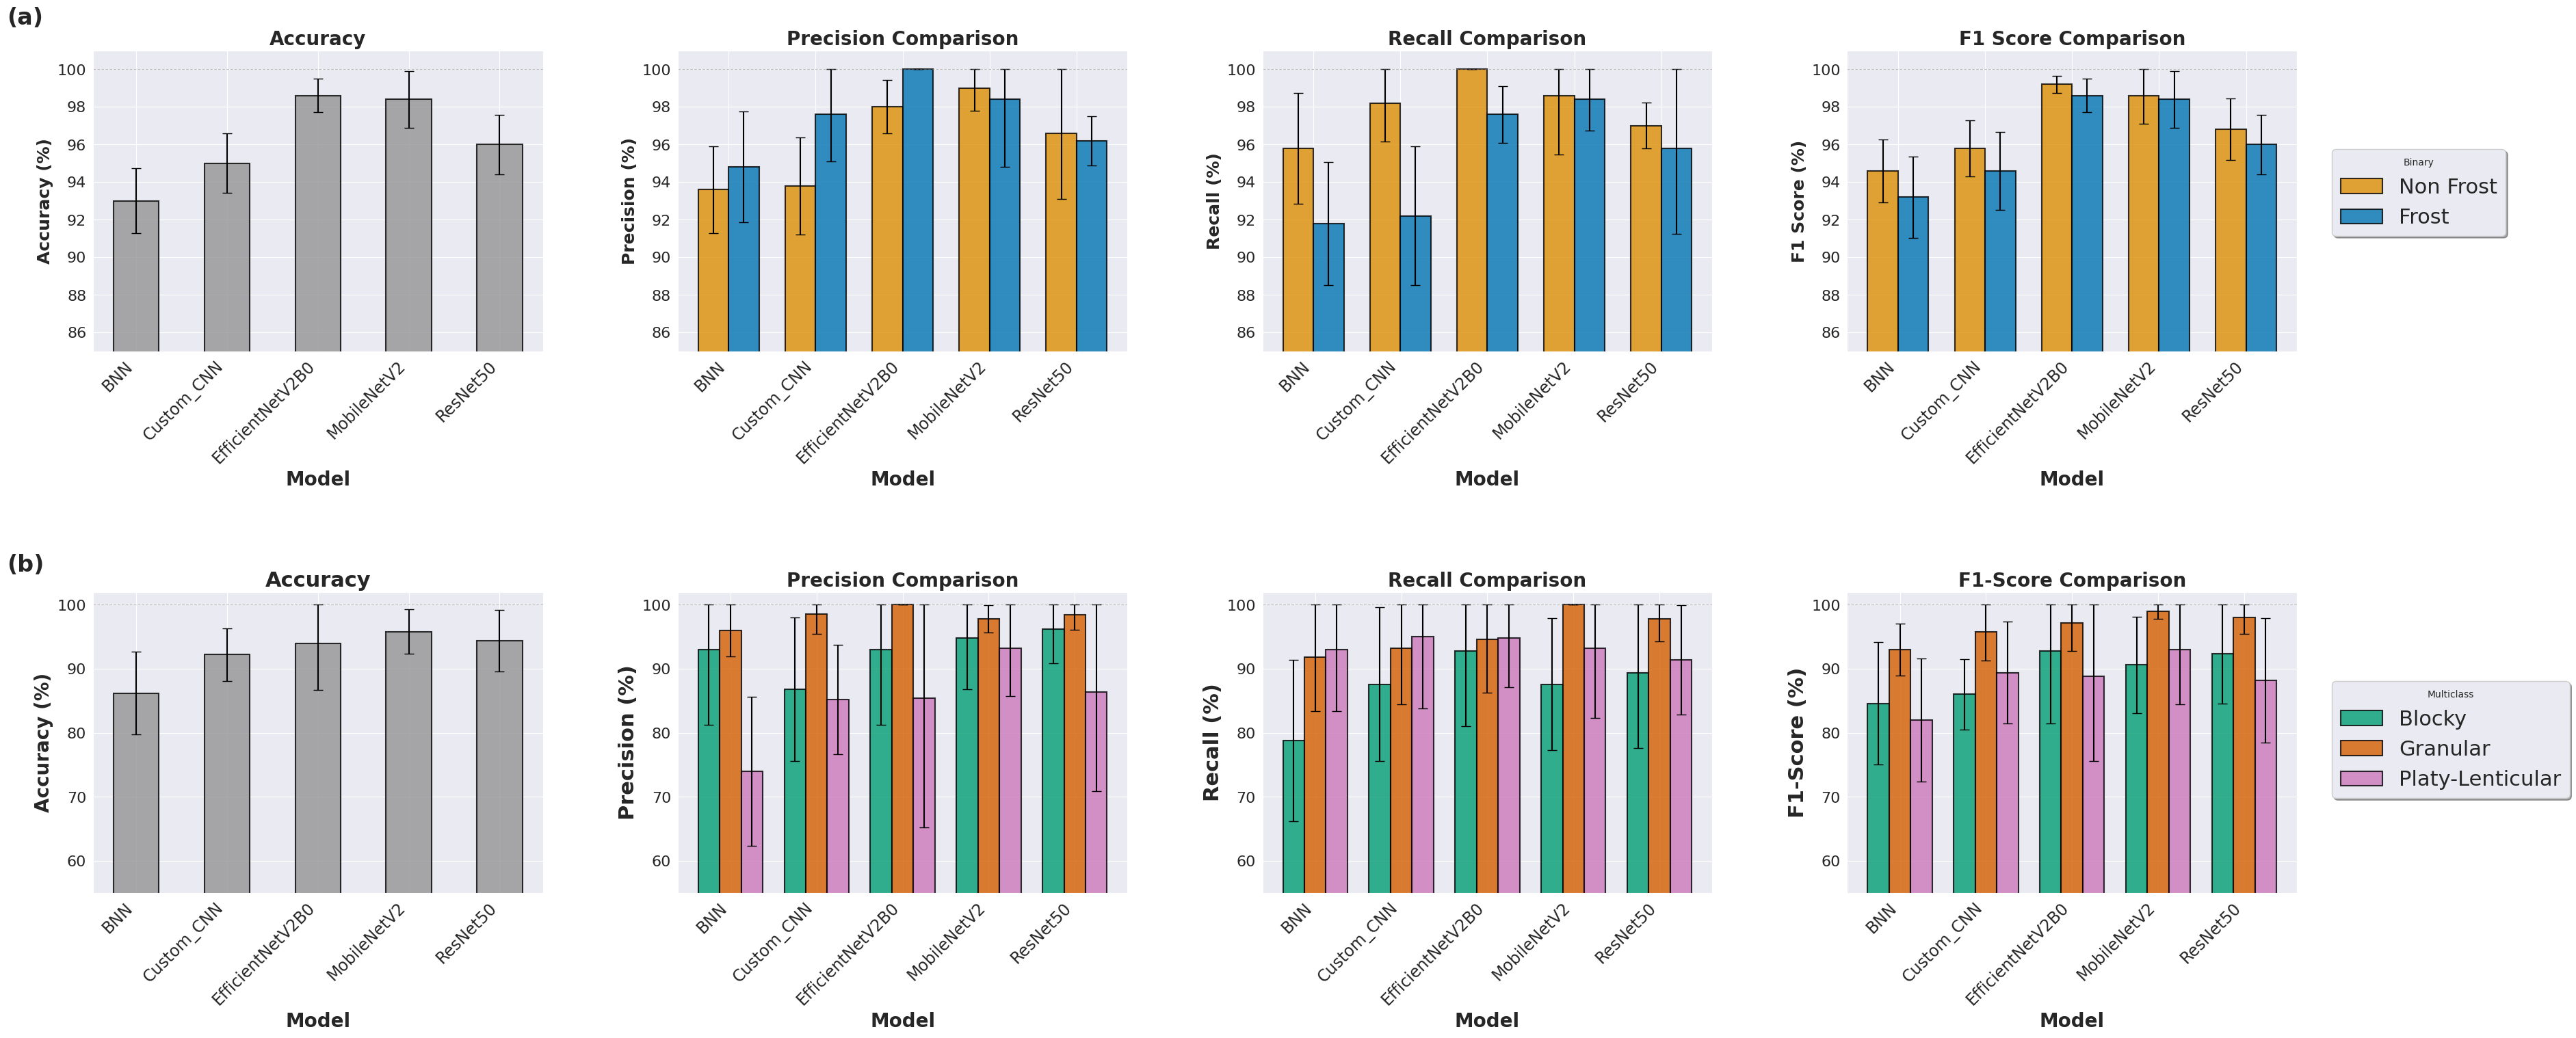

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('darkgrid')

# ==========================================
# READ AND PREPARE BINARY DATA
# ==========================================
df_binary = pd.read_excel(file_path, sheet_name='ml_results_binary')
df_binary['Base_Model'] = df_binary['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_binary_cv = df_binary[df_binary['Model'].str.contains('_f\d', regex=True)].copy()

# TODO: Check your actual column name for accuracy — it might be
# 'Accuracy', 'Val Accuracy', 'Validation Accuracy', etc.
# Print columns to verify: print(df_binary_cv.columns.tolist())

stats_binary = df_binary_cv.groupby('Base_Model').agg({
    'Accuracy': ['mean', 'std'],  # <-- adjust column name if needed
    'Precision Non Frost': ['mean', 'std'],
    'Recall Non Frost': ['mean', 'std'],
    'F1 Score Non frost': ['mean', 'std'],
    'Precision Frost': ['mean', 'std'],
    'Recall Frost': ['mean', 'std'],
    'F1 Score Frost': ['mean', 'std']
})

# ==========================================
# READ AND PREPARE MULTICLASS DATA
# ==========================================
df_multi = pd.read_excel(file_path, sheet_name='ml_results_multiclass')
df_multi['Base_Model'] = df_multi['Model'].str.replace(r'_(f\d|test)$', '', regex=True)
df_multi_cv = df_multi[df_multi['Model'].str.contains('_f\d', regex=True)].copy()

stats_multi = df_multi_cv.groupby('Base_Model').agg({
    'Accuracy': ['mean', 'std'],  # <-- adjust column name if needed
    'Precision  Blocky': ['mean', 'std'],
    'Recall Blocky': ['mean', 'std'],
    'F1-Score Blocky': ['mean', 'std'],
    'Precision Granular': ['mean', 'std'],
    'Recall Granular': ['mean', 'std'],
    'F1-Score Granular': ['mean', 'std'],
    'Precision Platy-Lenticular': ['mean', 'std'],
    'Recall Platy-Lenticular': ['mean', 'std'],
    'F1-Score Platy-Lenticular': ['mean', 'std']
})

# ==========================================
# DEFINE CONSISTENT COLOR SCHEME
# ==========================================
colorblind_palette = sns.color_palette('colorblind')

color_non_frost = colorblind_palette[1]      # Blue
color_frost_binary = colorblind_palette[0]   # Orange
color_blocky = colorblind_palette[2]         # Green
color_granular = colorblind_palette[3]       # Red
color_platy = colorblind_palette[4]          # Purple
color_accuracy = colorblind_palette[7]       # Gray — neutral for overall metric

# ==========================================
# CREATE 2x4 SUBPLOT LAYOUT
# ==========================================
fig, axes = plt.subplots(2, 4, figsize=(36, 16))
#plt.subplots_adjust(hspace=1.2)

# ==========================================
# PLOT BINARY ACCURACY (TOP ROW, FIRST COLUMN)
# ==========================================
ax = axes[0, 0]
x_binary = np.arange(len(stats_binary.index))

means_acc = stats_binary['Accuracy']['mean'] * 100
stds_acc = stats_binary['Accuracy']['std'] * 100
upper_err_acc = np.minimum(stds_acc, 100 - means_acc)
errors_acc = [stds_acc, upper_err_acc]

ax.bar(x_binary, means_acc, 0.5, yerr=errors_acc,
       capsize=5, color=color_accuracy,
       edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=20, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=18, fontweight='bold')
ax.set_title('Accuracy', fontsize=20, fontweight='bold')
ax.set_xticks(x_binary)
ax.set_xticklabels(stats_binary.index, rotation=45, ha='right', fontsize=17)
ax.set_ylim(85, 101)
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.tick_params(axis='y', labelsize=16)

# ==========================================
# PLOT BINARY PER-CLASS METRICS (TOP ROW, COLUMNS 2-4)
# ==========================================
metrics_binary = [
    ('Precision', 'Precision Non Frost', 'Precision Frost'),
    ('Recall', 'Recall Non Frost', 'Recall Frost'),
    ('F1 Score', 'F1 Score Non frost', 'F1 Score Frost')
]

width_binary = 0.35
colors_binary = [color_non_frost, color_frost_binary]

for idx, (metric_name, non_frost_col, frost_col) in enumerate(metrics_binary):
    ax = axes[0, idx + 1]  # Columns 1-3 (shifted by 1)

    means_non_frost = stats_binary[non_frost_col]['mean'] * 100
    stds_non_frost = stats_binary[non_frost_col]['std'] * 100
    means_frost = stats_binary[frost_col]['mean'] * 100
    stds_frost = stats_binary[frost_col]['std'] * 100

    upper_err_non_frost = np.minimum(stds_non_frost, 100 - means_non_frost)
    upper_err_frost = np.minimum(stds_frost, 100 - means_frost)
    errors_non_frost = [stds_non_frost, upper_err_non_frost]
    errors_frost = [stds_frost, upper_err_frost]

    bars1 = ax.bar(x_binary - width_binary/2, means_non_frost, width_binary,
                   yerr=errors_non_frost, capsize=5, label='Non Frost',
                   color=colors_binary[0], edgecolor='black', linewidth=1.5, alpha=0.8)
    bars2 = ax.bar(x_binary + width_binary/2, means_frost, width_binary,
                   yerr=errors_frost, capsize=5, label='Frost',
                   color=colors_binary[1], edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=20, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=18, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=20, fontweight='bold')
    ax.set_xticks(x_binary)
    ax.set_xticklabels(stats_binary.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(85, 101)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='y', labelsize=16)

# ==========================================
# PLOT MULTICLASS ACCURACY (BOTTOM ROW, FIRST COLUMN)
# ==========================================
ax = axes[1, 0]
x_multi = np.arange(len(stats_multi.index))

means_acc_m = stats_multi['Accuracy']['mean'] * 100
stds_acc_m = stats_multi['Accuracy']['std'] * 100
upper_err_acc_m = np.minimum(stds_acc_m, 100 - means_acc_m)
errors_acc_m = [stds_acc_m, upper_err_acc_m]

ax.bar(x_multi, means_acc_m, 0.5, yerr=errors_acc_m,
       capsize=5, color=color_accuracy,
       edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Model', fontsize=20, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=20, fontweight='bold')
ax.set_title('Accuracy', fontsize=22, fontweight='bold')
ax.set_xticks(x_multi)
ax.set_xticklabels(stats_multi.index, rotation=45, ha='right', fontsize=17)
ax.set_ylim(55, 102)
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.tick_params(axis='y', labelsize=16)

# ==========================================
# PLOT MULTICLASS PER-CLASS METRICS (BOTTOM ROW, COLUMNS 2-4)
# ==========================================
metrics_multi = [
    ('Precision', 'Precision  Blocky', 'Precision Granular', 'Precision Platy-Lenticular'),
    ('Recall', 'Recall Blocky', 'Recall Granular', 'Recall Platy-Lenticular'),
    ('F1-Score', 'F1-Score Blocky', 'F1-Score Granular', 'F1-Score Platy-Lenticular')
]

width_multi = 0.25
colors_multi = [color_blocky, color_granular, color_platy]
class_names = ['Blocky', 'Granular', 'Platy-Lenticular']

for idx, (metric_name, blocky_col, granular_col, platy_col) in enumerate(metrics_multi):
    ax = axes[1, idx + 1]  # Columns 1-3 (shifted by 1)

    columns = [blocky_col, granular_col, platy_col]

    for class_idx, (col, class_name, color) in enumerate(zip(columns, class_names, colors_multi)):
        means = stats_multi[col]['mean'] * 100
        stds = stats_multi[col]['std'] * 100
        upper_err = np.minimum(stds, 100 - means)
        errors = [stds, upper_err]
        position = x_multi + width_multi * (class_idx - 1)

        bars = ax.bar(position, means, width_multi, yerr=errors,
                     capsize=5, label=class_name, color=color,
                     edgecolor='black', linewidth=1.5, alpha=0.8)

    ax.set_xlabel('Model', fontsize=20, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (%)', fontsize=22, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=20, fontweight='bold')
    ax.set_xticks(x_multi)
    ax.set_xticklabels(stats_multi.index, rotation=45, ha='right', fontsize=17)
    ax.set_ylim(55, 102)
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='y', labelsize=16)

# ==========================================
# ADD (a) and (b) LABELS OUTSIDE PLOTS
# ==========================================
fig.text(-0.01, 0.92, '(a)', fontsize=24, fontweight='bold', va='top', ha='left')
fig.text(-0.01, 0.42, '(b)', fontsize=24, fontweight='bold', va='top', ha='left')

# ==========================================
# ADD LEGENDS ON THE RIGHT SIDE OF EACH ROW
# ==========================================
# Legend for binary (right side of top row)
handles_binary, labels_binary = axes[0, 1].get_legend_handles_labels()
legend_binary = fig.legend(handles_binary, labels_binary,
                          loc='center left', bbox_to_anchor=(0.93, 0.75),
                          fontsize=22, frameon=True, shadow=True, markerscale=1.5,
                          title='Binary')

# Legend for multiclass (right side of bottom row)
handles_multi, labels_multi = axes[1, 1].get_legend_handles_labels()
legend_multi = fig.legend(handles_multi, labels_multi,
                         loc='center left', bbox_to_anchor=(0.93, 0.25),
                         fontsize=22, frameon=True, shadow=True, markerscale=1.5,
                         title='Multiclass')

plt.subplots_adjust(hspace=0.8, wspace=0.3, left=0.025, right=0.92)
#plt.tight_layout(rect=[0.025, 0, 0.92, 1])

# Save the figure
output_path = '/content/drive/My Drive/2combined_classification_performance_with_accuracy.tif'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()